# [LAB-11] 시계열 분석ㅣ06-ARIMA 진단 및 평가(실습코드).ipynb

## #01. 준비작업 

### 1.라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame 
import numpy as np

# 잔차의 자기상관 검정 (Ljung-Box)
from statsmodels.stats.diagnostic import acorr_ljungbox

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기 + 인덱스 설정 

In [2]:
origin = load_data('air_passengers')
df = my_ts.set_index(origin, "Month", freq="MS")
df.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### 5단원의 결론 재현 
SARIMA(0,1,1)(0,1,1)12 모형을 재현한다 

In [3]:
# 5단원이 확정한 차수를 그대로 재현한다
p, d, q = (0, 1, 1)
P, D, Q, s = (0, 1, 1, 12)

# 모델링 
fit = my_ts.fit_model(df, "Passengers", log=True,
                      p=p, d=d, q=q, P=P, D=D, Q=Q, s=s)

시도한 조합 4가지 | 적합 성공 4가지 | 로그변환 적용
AIC 최적: (0, 1, 1)(0, 1, 1, 12) | BIC 최적: (0, 1, 1)(0, 1, 1, 12)


,모형,p,d,q,P,D,Q,s,계수 수,AIC,BIC
순위,,,,,,,,,,,
1,"(0, 1, 1)(0, 1, 1, 12)",0,1,1,0,1,1,12,3,-483.393,-474.767
2,"(0, 1, 0)(0, 1, 1, 12)",0,1,0,0,1,1,12,2,-467.553,-461.802
3,"(0, 1, 1)(0, 1, 0, 12)",0,1,1,0,1,0,12,2,-449.978,-444.228
4,"(0, 1, 0)(0, 1, 0, 12)",0,1,0,0,1,0,12,1,-434.830,-431.955


## #02. 잔차 확인 

### 1. 잔차 꺼내기 
차분이 d + D x s = 1+1x12 = 13시점을 소모한다.\
모형은 이 구간에서 아직 자리를 잡지 못한 상태라 잔차가 비정상적으로 크다.\

13개를 잘라내고 잔차를 확인해야 한다 

In [4]:
BURN = 1 + 1 * 12 # d + D x s : 차분이 소모하는 시점 수 

resid = fit.resid[BURN: ] # 차분이 소모하는 시점 이후의 잔차만 추출 
resid.name = "잔차"

print(f"전체 잔차 {len(fit.resid)}개")
print(f"진단 대상 {len(resid)}개 (앞 {BURN}개 제외)")   
print(f"평균 {resid.mean():.5f} | 표준편차 {resid.std():.5f}")

전체 잔차 144개
진단 대상 131개 (앞 13개 제외)
평균 0.00101 | 표준편차 0.03768


### 2. 잔차의 모습 살펴보기 
시간의 흐름에 따른 잔차의 흐름 lineplot 과 분포 histplot + KDE plot를 나란히 그려본다 

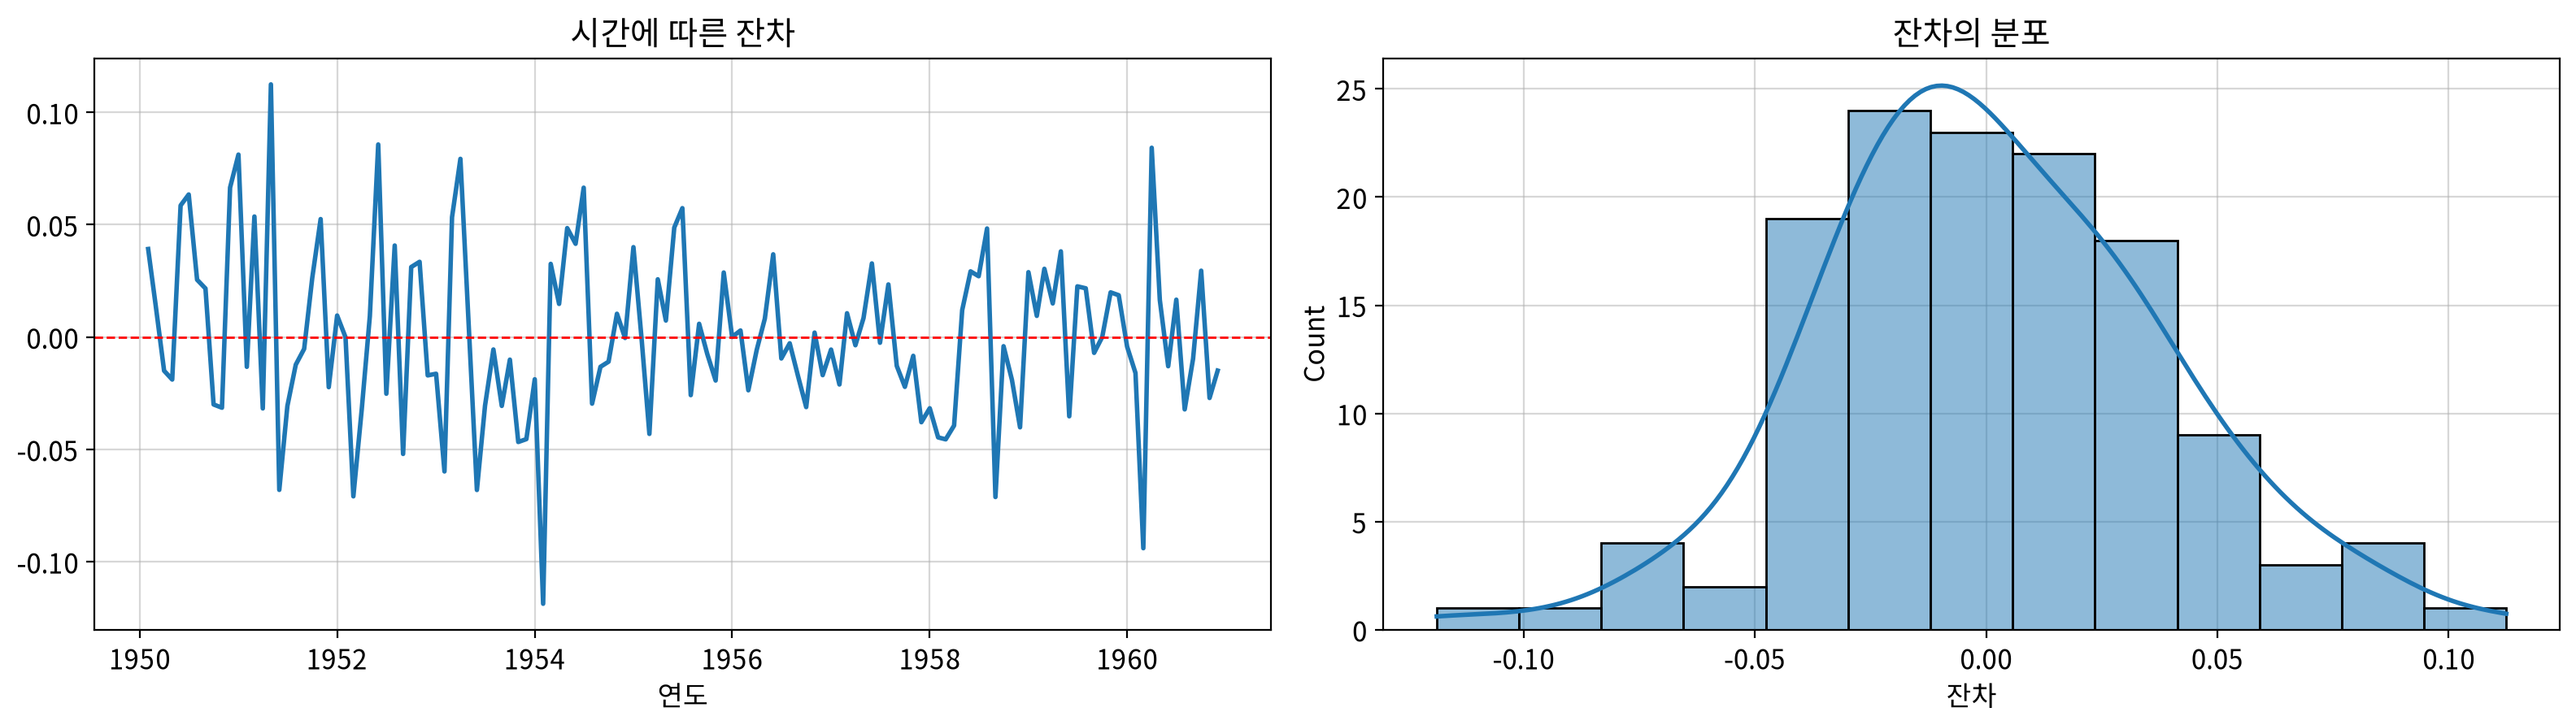

In [5]:
fig, ax = my_plot.init(rows=1, cols=2, width=800, height=480)

# 시간에 따른 잔차 : 0 주변을 무작위로 오가야 한다 
my_plot.lineplot(x=resid.index, y=resid.values, ax=ax[0])
ax[0].axhline(0, color="red", linestyle="--", linewidth=1)
ax[0].set_title("시간에 따른 잔차")
ax[0].set_xlabel("연도")

# 잔차의 분포 : 종 모양이어야 한다 
my_plot.histplot(data=resid.to_frame(), x="잔차", kde=True, ax=ax[1])
ax[1].set_title("잔차의 분포")

my_plot.show()

# 결과 확인 
왼쪽 - 시간에 따른 잔차 \
0을 중심으로 위아래를 무작위로 오간다 \
추세도 주기도 보이지 않는다 

오른쪽 - 잔차의 분포 \
0을 중심으로 대칭인 종 모양이다 

## # 잔차의 무상관 - Ljung-Box 검정 
### 여러 시차를 한 묶음으로 한 번에 검정해 "남은 자기상관이 있는가"를 판정한다 

## #03. ARIMA 의 가정 점검 
### 1. 잔차의 무상관 - Ljung - Box 검정 
여러 시차를 한 묶음으로 한 번에 검정해 "남은 자기상관이 있는가"를 판정한다 

In [6]:
# 파라미터 --> 잔차, 시차(12, 24), 결과 데이터 프레임 반환 (True)
lb = acorr_ljungbox(resid, lags=[12,24], return_df=True)    

# p-value가 0.05 이상이면 자기 상관이 없다고 판단한다 
lb["판정"] = np.where(lb["lb_pvalue"] >= 0.05, 
                    "통과 (자기상관 없음)", "실패 (자기상관 남음)") 
lb.index.name = "검정 시차"

lb.round(4)

,lb_stat,lb_pvalue,판정
검정 시차,,,
12,8.470,0.747,통과 (자기상관 없음)
24,23.621,0.483,통과 (자기상관 없음)


## # 잔차의 정규성 - Jarque-Bera 검정 
왜도와 첨도를 하나의 통계량으로 묶어 정규분포 여부를 판정한다 

In [7]:
jb_stat, jb_p, skew, kurtosis = fit.test_normality("jarquebera")[0]

print(f"Jarque-Bera 통계량 {jb_stat:.3f} | p-value {jb_p:.4f}") 
print(f"왜도 {skew:.3f} (0에 가까울수록 대칭)")
print(f"첨도 {kurtosis:.3f} (3에 가까울 수록 정규분포)")
print("판정:", "통과 (정규성 만족)" if jb_p >= 0.05 else "실패 (정규성 위배)")

Jarque-Bera 통계량 1.898 | p-value 0.3872
왜도 0.023 (0에 가까울수록 대칭)
첨도 3.588 (3에 가까울 수록 정규분포)
판정: 통과 (정규성 만족)


## # 잔차의 등분산 - 이분산 검정 
잔차의 흔들림이 구간에 관계없이 일정한지 두 구간의 분산비로 판정한다 

In [8]:
h_stat, h_p = fit.test_heteroskedasticity("breakvar")[0]

print(f"이분산 통계량 H {h_stat:.3f} | p-value {h_p:.4f}")
print("분산의 방향: ", "뒤로 갈수록 커짐" if h_stat >1 else "뒤로 갈수록 작아짐")
print("판정: ", "통과 (등분산)" if h_p >= 0.05 else "실패 (이분산)")

이분산 통계량 H 0.581 | p-value 0.0752
분산의 방향:  뒤로 갈수록 작아짐
판정:  통과 (등분산)


## # 진단 종합과 우선순위 
세 가정 모두 통과 -> 이 차수를 최종 모형으로 확정한다 

## # 주요성능 지표 
무엇을 재고 싶은가에 따라 지표를 고른다 

## # 기준선과 비교하기 : 계절 나이브 
성능 지료는 혼자 보면 잘한 것인지 알 수 없다 - 비교 대상이 필요하다 

## #04. 적합도 평가 
### 1. 관측값 얻기 

In [9]:
# 모형이 실제로 학습한 시계열은 결과 객체가 그대로 들고 있다. 
# --> fit_model(log=True) 이 내부에서 로그를 씌워 놓은 상태이다. 
log_s = fit.model.data.orig_endog # 로그 스케일 관측값 

# 로그 스케일 -> 원래 단위 (승객 수)로 되돌린다 
actual = np.exp(log_s[BURN:]) # 관측값 
print(f"실제 관측값 {len(actual)}개")

실제 관측값 131개


### 2. 예측값 얻기 

In [10]:
# 예측값도 로그 스케일이므로 원래 단위로 되돌린다 
fitted = np.exp(fit.fittedvalues[BURN:]) # ARIMA의 적합값 
print(f"적합값 {len(fitted)}개")

적합값 131개


### 3. 계절 나이브 얻기 

In [11]:
# 계절 나이브 : 작년 같은 달의 값을 그대로 예측값으로 쓴다 
naive = df["Passengers"].shift(12)[BURN:]   
print(f"계절 나이브 {len(naive)}개")

계절 나이브 131개


### 4. 적합도 평가표 구성 

In [12]:
# 오차 = 관측값 - 예측값 
arima_error = actual.values - fitted.values # ARIMA 적합값의 오차 
naive_error = actual.values - naive.values # 계절 나이브(기준선)의 오차 

# 지표를 바로 계산해 한 표로 묶는다.
DataFrame([{
    "대상": "ARIMA 적합값", 
    "관측치 수": len(arima_error),
    "MAE": np.mean(np.abs(arima_error)), # 오차 절댓값의 평균
    "RMSE": np.sqrt(np.mean(arima_error **2)), # 오차 제곱 평균의 제곱근 
    "MAPE(%)": np.mean(np.abs(arima_error / actual.values))*100 # 오차 비율의 평균 (%)
}, {
    "대상": "계절 나이브 (기준선)", 
    "관측치 수": len(naive_error),
    "MAE": np.mean(np.abs(naive_error)),
    "RMSE": np.sqrt(np.mean(naive_error **2)), 
    "MAPE(%)": np.mean(np.abs(naive_error / actual.values))*100
}]).set_index("대상").round(3)


,관측치 수,MAE,RMSE,MAPE(%)
대상,,,,
ARIMA 적합값,131,8.157,10.715,2.924
계절 나이브 (기준선),131,32.252,36.453,11.315


## 4. 적합도 평가표 구성 (결과 확인)

| 대상 | 관측치 수 | MAE | RMSE | MAPE(%) |
|---|---:|---:|---:|---:|
| ARIMA 적합값 | 131 | 8.157 | 10.715 | 2.924 |
| 계절 나이브 (기준선) | 131 | 32.252 | 36.453 | 11.315 |

- **MAPE 2.924%** — 평균적으로 실제값에서 2.924% 벗어난다. 승객 300명 규모에서 약 9명 오차이므로 **매우 잘 따라가고 있다.**
- **기준선(계절 나이브) 대비 오차가 1/4 수준이다.** (11.315% → 2.924%) — ARIMA가 추세와 오차 구조를 학습한 효과가 이 차이다.
- 계절 나이브가 11.315%나 틀리는 이유는 **이 데이터가 매년 증가**하기 때문이다. 작년 같은 달을 그대로 쓰면 **증가분만큼 항상 모자란다.**

> **이 숫자는 "모형이 이미 본 데이터"에 대한 값이다.**
> 그래서 **"얼마나 잘 따라가는가(적합도)"**는 말할 수 있어도 **"내년을 얼마나 맞히는가"**를 그대로 보장하지는 않는다. 이 단원은 **모형이 데이터를 얼마나 잘 설명하는가**까지를 다룬다.

# 2. 잔차 진단 모듈화 

진단 대상 131개 (앞 13개 제외) | 유의수준 0.05
실패한 검정: 없음 (모든 가정 통과)


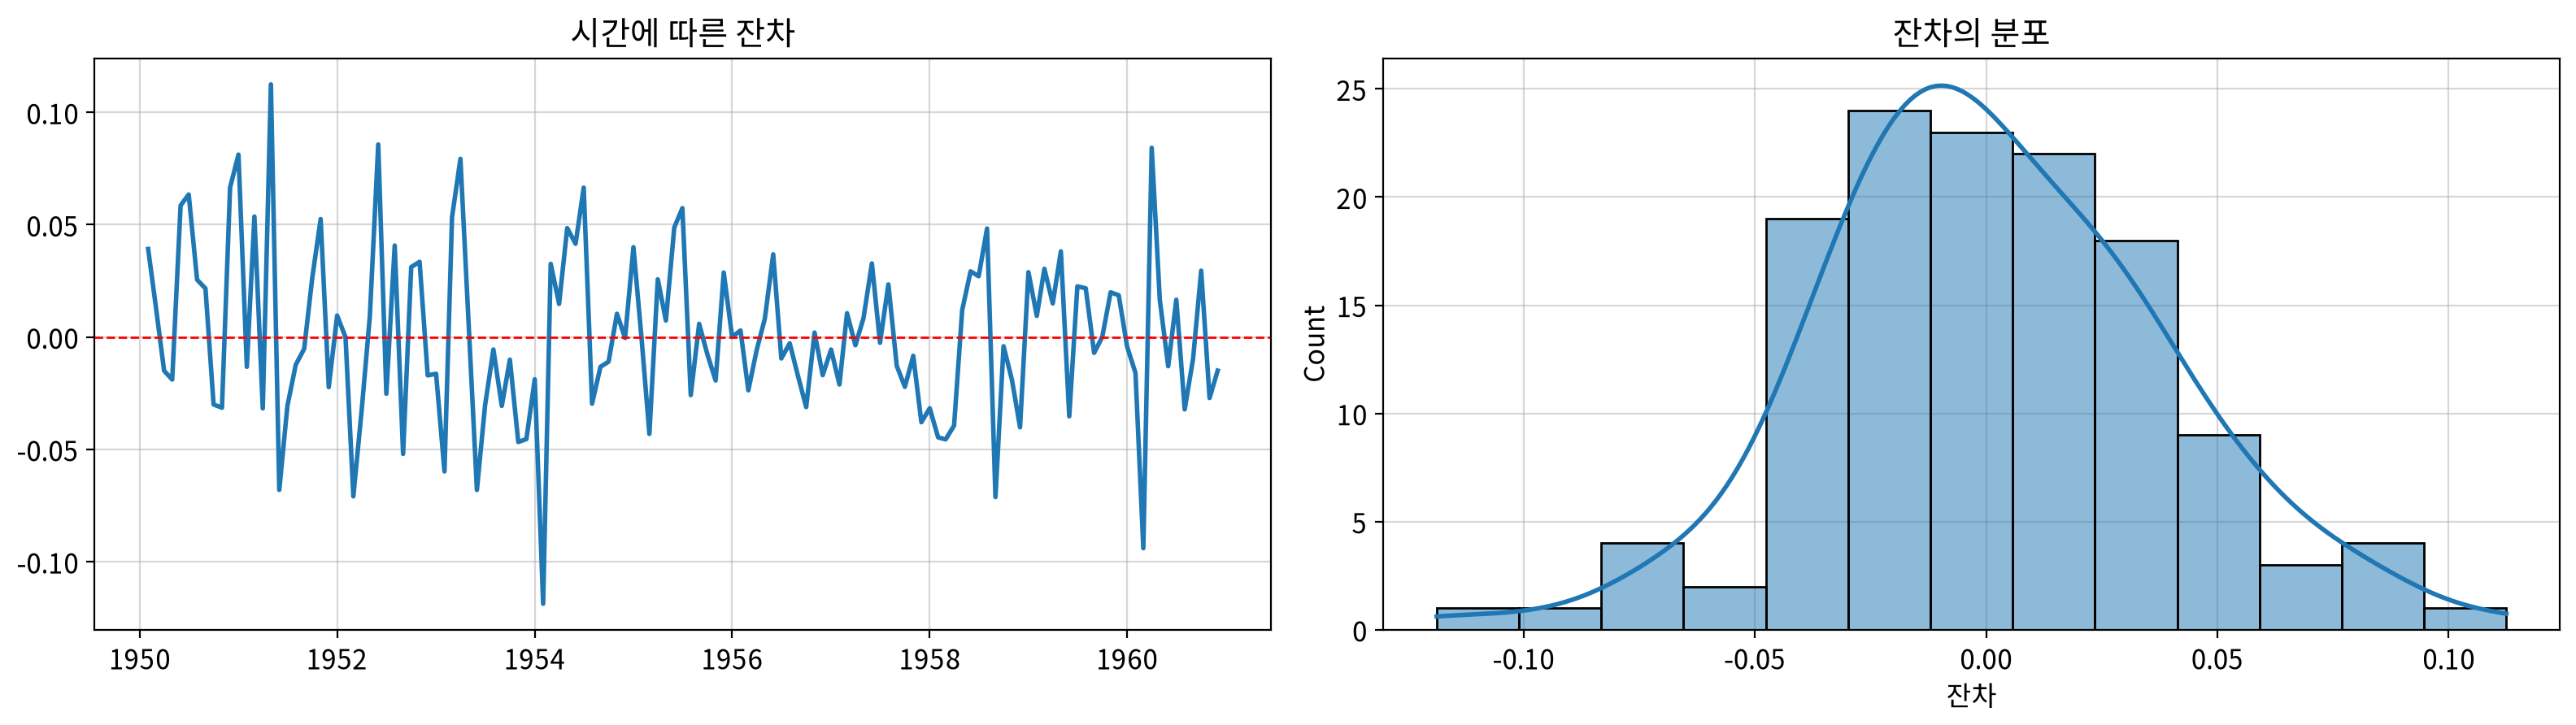

,가정,관측치 수,통계량,p-value,통과,판정,비고
검정,,,,,,,
Ljung-Box (시차 12),무상관,131,8.470,0.583,True,통과 (자기상관 없음),자유도 10
Ljung-Box (시차 24),무상관,131,23.621,0.367,True,통과 (자기상관 없음),자유도 22
Jarque-Bera,정규성,131,1.898,0.387,True,통과 (정규성 만족),왜도 0.023 · 첨도 3.588
이분산(H),등분산성,131,0.581,0.075,True,통과 (등분산),뒤로 갈수록 작아짐


In [13]:
my_ts.report_residual(fit)

### 2. 적합도 평가 

In [14]:
# name 파라미터가 없으면 "적합값"으로 기본 설정됨 
my_ts.report_score(fit, name="ARIMA 적합값")

평가 구간 131개 (1950-02-01 00:00:00 ~ 1960-12-01 00:00:00)
MAPE 2.195% → 0.531% | 기준선 대비 75.8% 개선


,관측치 수,MAE,RMSE,MAPE(%)
대상,,,,
ARIMA 적합값,131,0.029,0.038,0.531
계절 나이브 (시차 12),131,0.122,0.135,2.195


## # 연습문제